## 1: Import Libraries

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

## 2 : Dataset Paths

In [9]:
train_path = r"D:\Projects\Facial Emotion Recognition\notebook\data\train"

test_path = r"D:\Projects\Facial Emotion Recognition\notebook\data\test"

### 3: Check Dataset Distribution

In [ ]:
print("Training Dataset Distribution\n")

for emotion in os.listdir(train_path):
    emotion_path = os.path.join(train_path, emotion)

    if os.path.isdir(emotion_path):
        print(f"{emotion:<10} : {len(os.listdir(emotion_path))}")

Training Dataset Distribution

angry      : 3995
disgust    : 436
fear       : 4097
happy      : 7215
neutral    : 4965
sad        : 4830
surprise   : 3171


## 4: Data Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

## 5: Load Dataset

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## 7: Build CNN Model

In [ ]:
model = Sequential()

model.add(Input(shape=(48, 48, 1)))

model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(256, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(7, activation="softmax"))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 44, 44, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 20, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 20, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 18, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 5, 5, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 553,575 (2.11 MB)

 Trainable params: 553,127 (2.11 MB)

 Non-trainable params: 448 (1.75 KB)

## 8: Compile Model

In [ ]:

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## 9: EarlyStopping

In [ ]:
os.makedirs("artifacts", exist_ok=True)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

## 10: ModelCheckpoint

In [ ]:
checkpoint = ModelCheckpoint(
    "artifacts/model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)


In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

 ## 11: Train Model

In [ ]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=50,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1460 - loss: 2.2290
Epoch 1: val_accuracy improved from None to 0.18682, saving model to best_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 697s 2s/step - accuracy: 0.1525 - loss: 2.0350 - val_accuracy: 0.1868 - val_loss: 1.9330
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.1414 - loss: 1.9623
Epoch 2: val_accuracy did not improve from 0.18682
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.1416 - loss: 1.9373 - val_accuracy: 0.1101 - val_loss: 1.9086
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.1450 - loss: 1.9033
Epoch 3: val_accuracy improved from 0.18682 to 0.21622, saving model to best_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 80s 179ms/step - accuracy: 0.1518 - loss: 1.9123 - val_accuracy: 0.2162 - val_loss: 1.8170
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.1559 - loss: 1.9102
Epoch 4: val_accuracy improved from 0.21622 to 0.24143, saving mode

## 13: Accuracy & Loss Graph

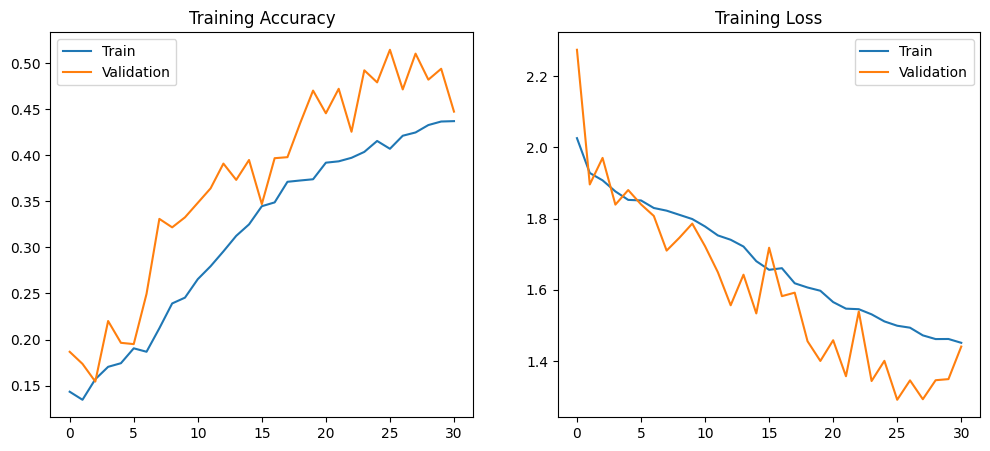

In [ ]:

os.makedirs("results", exist_ok=True)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.savefig("results/accuracy_loss_curve.png", bbox_inches="tight")
plt.show()

## 14: Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(test_generator)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5146 - loss: 1.2918
Test Loss : 1.2918
Test Accuracy : 0.5146


## 15: Classification Report

              precision    recall  f1-score   support

       angry       0.39      0.31      0.35       958
     disgust       0.29      0.52      0.37       111
        fear       0.24      0.03      0.05      1024
       happy       0.75      0.78      0.77      1774
     neutral       0.42      0.66      0.52      1233
         sad       0.42      0.33      0.37      1247
    surprise       0.52      0.83      0.64       831

    accuracy                           0.51      7178
   macro avg       0.43      0.50      0.44      7178
weighted avg       0.48      0.51      0.48      7178



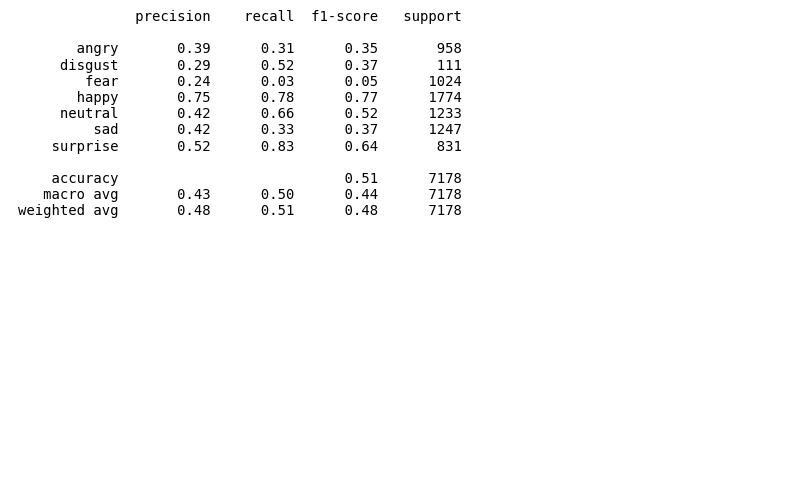

In [ ]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
)

print(report)

with open("results/classification_report.txt", "w") as f:
    f.write(report)

plt.figure(figsize=(10, 6))
plt.axis("off")
plt.text(
    0.01,
    1.0,
    report,
    fontsize=10,
    family="monospace",
    verticalalignment="top"
)

plt.savefig("results/classification_report.png", bbox_inches="tight")
plt.show()

## 16: Confusion Matrix

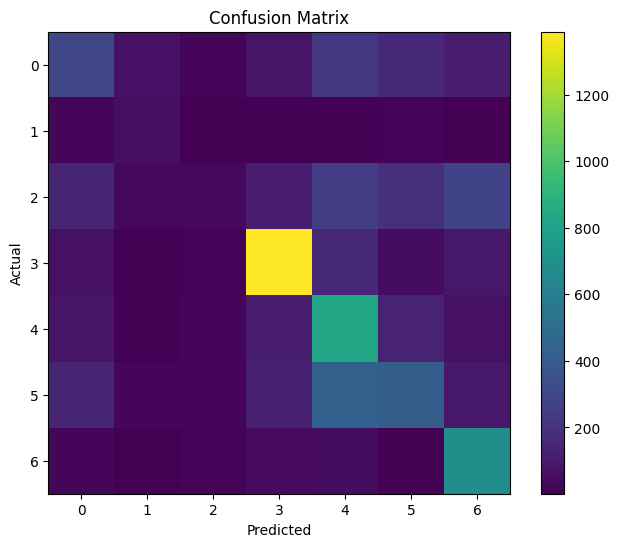

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.colorbar()

plt.xticks(
    ticks=np.arange(len(class_names)),
    labels=class_names,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(class_names)),
    labels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("results/confusion_matrix.png", bbox_inches="tight")
plt.show()

## 17: Save Model

In [ ]:
os.makedirs("artifacts", exist_ok=True)

model.save("artifacts/final_model.keras")

print("Model Saved Successfully")
print("Best Model Path: artifacts/model.keras")
print("Final Model Path: artifacts/final_model.keras")